In [222]:
import pandas as pd
import numpy as np



In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

import pandas as pd

# =========================
# 1. READ CSV FILES
# =========================
q_max = pd.read_csv("q_max.csv")
q_min = pd.read_csv("q_min.csv")
q_sred = pd.read_csv("q_sred.csv")

# =========================
# 2. NORMALIZE COLUMN NAMES
# =========================
# lowercase, remove spaces
for df in [q_max, q_min, q_sred]:
    df.columns = df.columns.str.strip().str.lower()

# =========================
# 3. DEFINE MONTHS
# =========================
months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]

# check which months actually exist in the dataframe
for name, df in zip(["q_max", "q_min", "q_sred"], [q_max, q_min, q_sred]):
    existing_months = [m for m in months if m in df.columns]
    print(f"{name} has columns: {existing_months}")

    # convert existing month columns to numeric
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors="coerce")

q_max has columns: ['jan', 'feb', 'mar', 'apr', 'maj', 'jun', 'jul', 'avg', 'sep', 'okt', 'nov', 'dec']
q_min has columns: ['jan', 'feb', 'mar', 'apr', 'maj', 'jun', 'jul', 'avg', 'sep', 'okt', 'nov', 'dec']
q_sred has columns: ['jan', 'feb', 'mar', 'apr', 'maj', 'jun', 'jul', 'avg', 'sep', 'okt', 'nov', 'dec']


In [224]:
df.rename(columns={"unnamed: 0": "years"}, inplace=True)
df

,years,jan,feb,mar,apr,maj,jun,jul,avg,sep,okt,nov,dec,god
0,1961,132.60,163.00,141.20,115.30,352.80,127.70,50.70,31.4,23.2,73.00,118.80,137.40,122.3
1,1962,175.00,227.40,461.00,536.70,165.30,74.70,62.30,29.7,23.0,24.70,119.30,184.90,173.7
2,1963,292.10,400.60,266.00,277.30,163.50,154.90,67.40,43.7,40.9,36.10,57.20,116.20,159.7
3,1964,66.20,184.50,311.70,195.80,163.20,172.50,133.80,88.2,69.6,284.30,374.70,389.30,202.8
4,1965,225.50,209.80,377.10,299.50,541.00,156.70,65.40,39.2,59.1,34.10,95.70,233.30,194.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2021,181.44,186.22,101.82,116.45,68.05,34.21,29.37,18.7,17.3,43.64,192.62,309.69,108.3
61,2022,112.30,92.60,84.70,121.30,62.80,58.00,21.60,23.6,31.5,23.90,60.50,130.40,68.6
62,2023,199.20,108.70,256.20,220.00,233.70,275.20,58.50,29.5,26.1,21.30,111.80,116.70,138.1
63,2024,72.60,69.20,78.70,46.30,34.20,25.70,21.40,17.1,36.2,56.70,53.40,107.70,51.6


In [225]:
# analysis and prediction (q_min)

q_min.columns = q_min.columns.str.strip().str.lower()

# Define months
months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
existing_months = [m for m in months if m in q_min.columns]

# Convert to numeric
q_min[existing_months] = q_min[existing_months].apply(pd.to_numeric, errors="coerce")

# Fill missing values (simple approach)
q_min[existing_months] = q_min[existing_months].fillna(method='ffill').fillna(method='bfill')


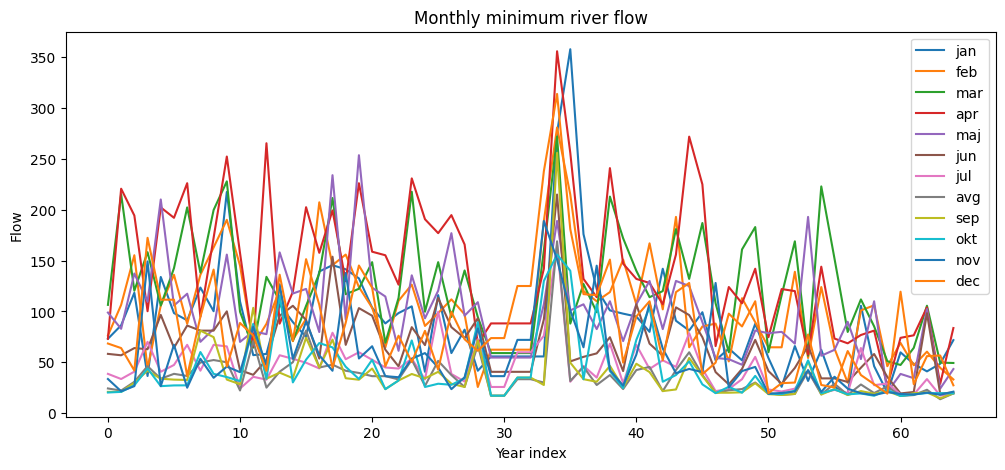

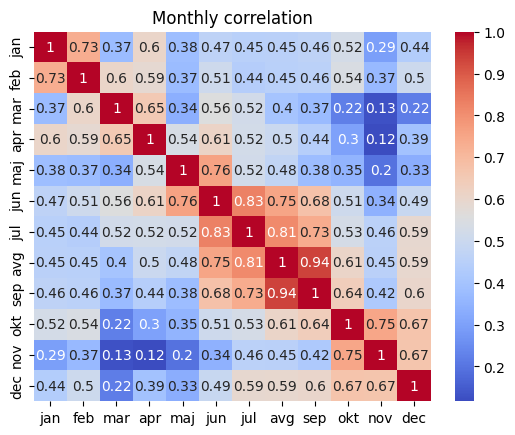

In [226]:
#2️Exploratory Analysis

import matplotlib.pyplot as plt

# Plot monthly trends
q_min[existing_months].plot(figsize=(12,5))
plt.title("Monthly minimum river flow")
plt.xlabel("Year index")
plt.ylabel("Flow")
plt.show()

# Correlation heatmap
import seaborn as sns
sns.heatmap(q_min[existing_months].corr(), annot=True, cmap="coolwarm")
plt.title("Monthly correlation")
plt.show()


In [227]:
## find patterns accross years:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(q_min[existing_months])

kmeans = KMeans(n_clusters=5, random_state=42)
q_min['cluster'] = kmeans.fit_predict(X_scaled)

# Show cluster counts
print(q_min['cluster'].value_counts())


0    25
4    14
2    13
3    12
1     1
Name: cluster, dtype: int64


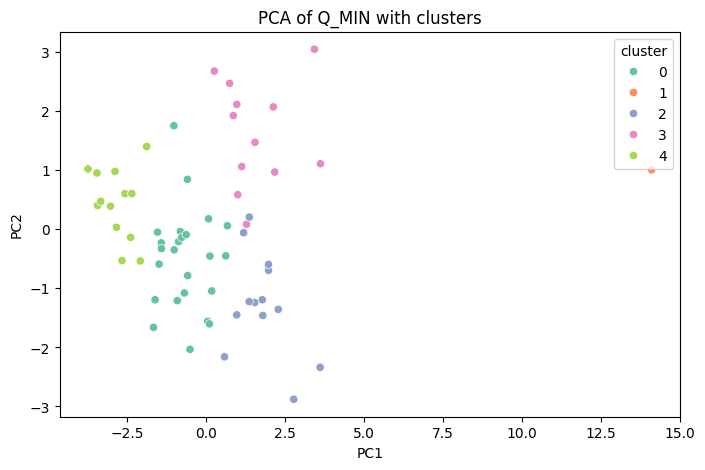

In [228]:
## PCA:

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)
q_min['PC1'] = components[:,0]
q_min['PC2'] = components[:,1]

plt.figure(figsize=(8,5))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=q_min, palette='Set2')
plt.title("PCA of Q_MIN with clusters")
plt.show()


Q_MIN - RF (Log + Seasonal) Metrics:
RMSE: 35.38
MAE : 23.67
NSE : 0.2908


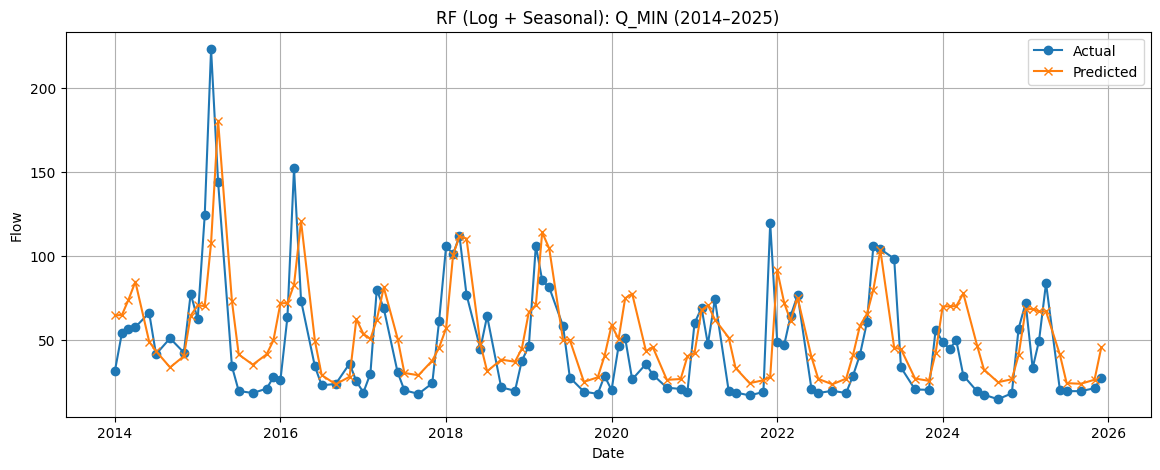

array([ 64.38015485,  64.75901974,  73.57652901,  84.48353994,
        48.77837687,  43.18690435,  33.45910863,  40.15705818,
        64.31471867,  70.44575918,  69.95996183, 107.52759193,
       180.42418562,  72.99438907,  41.15283374,  35.09185719,
        41.23867975,  49.48805131,  71.62501571,  71.80538226,
        82.63814799, 120.40999266,  49.45697162,  28.86593032,
        23.4192845 ,  27.89021141,  62.23582411,  53.44688519,
        50.43284882,  61.72174854,  81.10261848,  50.61118469,
        30.12611504,  28.78720033,  37.51364813,  45.21700555,
        56.74094677, 100.6593931 , 111.45158284, 110.21722998,
        47.68156965,  31.13304762,  38.0735012 ,  36.85782241,
        44.56528127,  66.37453252,  70.61107833, 113.90485704,
       104.30331548,  49.66606775,  49.75673258,  24.85566852,
        27.527555  ,  40.25569733,  58.55932474,  50.338558  ,
        74.6439024 ,  77.33422418,  43.1485657 ,  45.55244737,
        26.04714406,  26.53483527,  40.13853578,  41.89

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # Nash–Sutcliffe Efficiency (NSE)
    denominator = np.sum((y_true - np.mean(y_true))**2)
    numerator = np.sum((y_true - y_pred)**2)
    nse = 1 - numerator / denominator if denominator != 0 else np.nan
    
    return rmse, mae, nse

#We built a complete time-series forecasting workflow for both q_max and q_min,
#treating the monthly flows as a true chronological series, 
#using a sliding-window Random Forest approach. 
#This will predict flows for 2014–2025 and plot predicted vs actual flows.

# -----------------------------
# 1. Function to prepare long time-series
# -----------------------------
def prepare_time_series(df, value_name='flow'):
    df.columns = df.columns.str.strip().str.lower()
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]
    
    # Convert to numeric
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')
    
    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    
    # Create datetime index
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    return ts

# -----------------------------
# 2. Function to create sliding windows
# -----------------------------
def create_sliding_windows(ts, window_size=12, value_name='flow'):
    flows = ts[value_name].values
    X, y = [], []
    for i in range(len(flows) - window_size):
        X.append(flows[i:i+window_size])
        y.append(flows[i+window_size])
    X = np.array(X)
    y = np.array(y)
    index = ts.index[window_size:]
    return X, y, index

# ------------------------------------------------------
# 3. Function to train, predict and plot
# --------------------------------------------------------

def forecast_time_series(df, label):
    ts = prepare_time_series(df, value_name='flow').copy()
    
    # -----------------------------
    # 1. Add seasonal signal
    # -----------------------------
    ts['month_num'] = ts.index.month
    
    # -----------------------------
    # 2. Sliding window + seasonality
    # -----------------------------
    window_size = 12
    
    flows = ts['flow'].values
    months = ts['month_num'].values
    dates = ts.index
    
    X, y, index = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        month_feat = months[i]
        
        X.append(np.append(lag_vals, month_feat))  # lag + season
        y.append(flows[i])
        index.append(dates[i])
    
    X = np.array(X)
    y = np.array(y)
    index = pd.to_datetime(index)

    # -----------------------------
    # 3. LOG TRANSFORM
    # -----------------------------
    y_log = np.log1p(y)

    # -----------------------------
    # 4. Train/test split
    # -----------------------------
    split_date = pd.to_datetime('2014-01-01')
    split_idx = np.where(index < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    X_train, y_train = X[:split], y_log[:split]
    X_test, y_test = X[split:], y[split:]   # keep original scale
    index_test = index[split:]

    # -----------------------------
    # 5. Train Random Forest
    # -----------------------------
    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=4,        # helps generalization
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # -----------------------------
    # 6. Predict + inverse transform
    # -----------------------------
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # -----------------------------
    # 7. Enforce non-negative
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 8. Align lengths
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    index_test = index_test[:min_len]

    # -----------------------------
    # 9. Metrics
    # -----------------------------
    rmse, mae, nse = compute_metrics(y_test, y_pred)

    print(f"\n{label} - RF (Log + Seasonal) Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse:.4f}")

    # -----------------------------
    # 10. Plot
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(index_test, y_test, label='Actual', marker='o')
    plt.plot(index_test, y_pred, label='Predicted', marker='x')
    plt.title(f"RF (Log + Seasonal): {label} (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{label}_rf_log_seasonal.png")
    plt.show()

    return y_pred
# -----------------------------
# 4. Run for Q_MAX and Q_MIN
# -----------------------------
#q_max = pd.read_csv("q_max.csv")
q_min = pd.read_csv("q_min.csv")

#forecast_time_series(q_max, "Q_MAX")
forecast_time_series(q_min, "Q_MIN")

#Handles both Q_MAX and Q_MIN in one pipeline.
#Converts wide monthly format to long time-series.
#Uses a sliding window of past 12 months to predict the next month.
#Respects chronological order — no shuffling.
#Computes MSE and plots actual vs predicted flows from 2014–2025.
#Works with any missing values — forward/backward filling included.

In [230]:
##single-step sliding window approach:


Q_MIN - Evaluation Metrics (LOG + SEASONAL):
RMSE: 33.78
MAE : 25.01
NSE : 0.3536


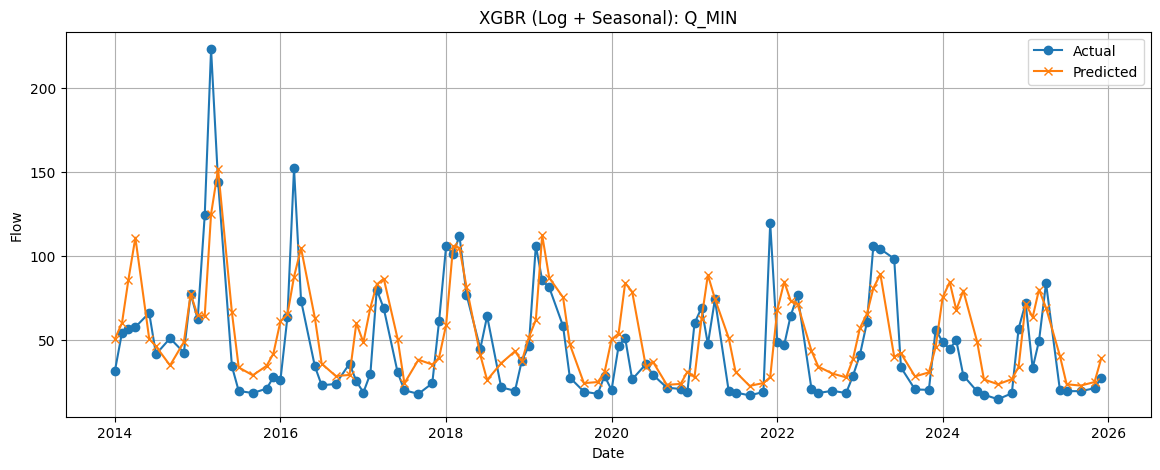

In [231]:
def sliding_window_forecast(ts, label, window_size=24, split_date='2014-01-01'):
    
    # -----------------------------
    # 0. Add seasonal feature
    # -----------------------------
    ts = ts.copy()
    ts['month_num'] = ts.index.month
    
    flows = ts['flow'].values
    months = ts['month_num'].values
    dates = ts.index

    # -----------------------------
    # 1. Create sliding windows + seasonality
    # -----------------------------
    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_values = flows[i-window_size:i]
        month_feature = months[i]  # current month
        
        # Combine lag + seasonal signal
        X.append(np.append(lag_values, month_feature))
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # -----------------------------
    # 2. LOG TRANSFORM TARGET
    # -----------------------------
    y_log = np.log1p(y)

    # -----------------------------
    # 3. Train/test split
    # -----------------------------
    split_date_ts = pd.to_datetime(split_date)
    split_indices = np.where(idx < split_date_ts)[0]
    split = split_indices[-1] + 1 if len(split_indices) > 0 else 0

    X_train, y_train = X[:split], y_log[:split]
    X_test, y_test = X[split:], y[split:]  # keep original scale for evaluation
    idx_test = idx[split:]

    # -----------------------------
    # 4. Train XGBoost
    # -----------------------------
    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # 5. Predict + inverse transform
    # -----------------------------
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)  # back to original scale

    # -----------------------------
    # 6. Enforce non-negative values
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 7. Align lengths
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx_test = idx_test[:min_len]

    # -----------------------------
    # 8. Metrics
    # -----------------------------
    rmse, mae, nse = compute_metrics(y_test, y_pred)

    print(f"\n{label} - Evaluation Metrics (LOG + SEASONAL):")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse:.4f}")

    # -----------------------------
    # 9. Plot
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx_test, y_test, label='Actual', marker='o')
    plt.plot(idx_test, y_pred, label='Predicted', marker='x')
    plt.title(f"XGBR (Log + Seasonal): {label}")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred


q_min = pd.read_csv("q_min.csv")

ts_qmin = prepare_time_series(q_min)

pred_qmin = sliding_window_forecast(ts_qmin, "Q_MIN")

#log-transform target
#✅ seasonal signal (month)
#✅ non-negative predictions
#✅ safe inverse transform
#✅ robust alignment


/home/marko/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Q_MIN - NN (Log + Seasonal) Metrics:
RMSE: 28.68
MAE : 20.55
NSE : 0.3236


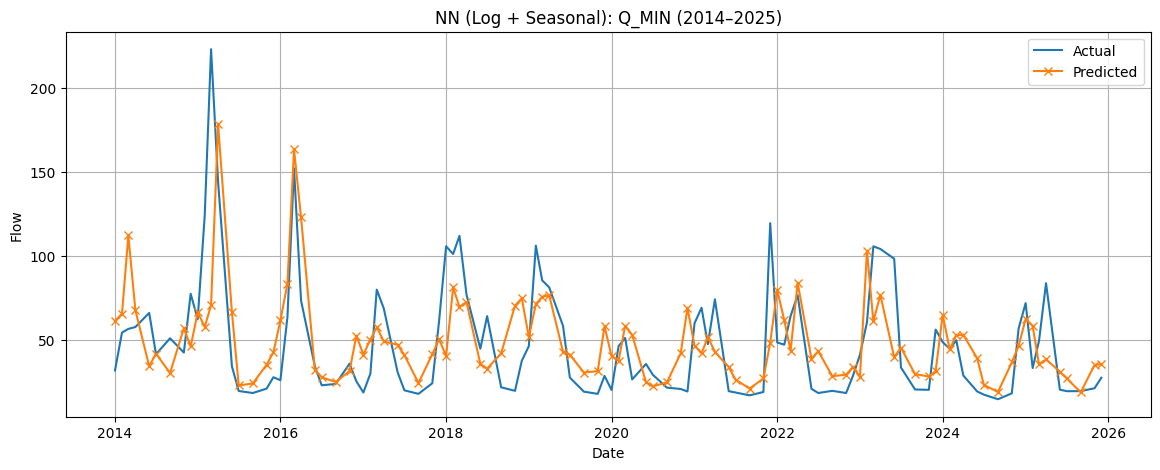

In [232]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def nn_forecast_improved(ts, label, window_size=12, start_plot='2014-01-01', end_plot='2025-12-01'):
    
    ts = ts.copy()
    
    # -----------------------------
    # 1. Ensure non-negative input
    # -----------------------------
    ts['flow'] = ts['flow'].clip(lower=0)

    # -----------------------------
    # 2. Seasonal encoding (BETTER)
    # -----------------------------
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    # -----------------------------
    # 3. Sliding window + seasonality
    # -----------------------------
    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # -----------------------------
    # 4. LOG TRANSFORM (critical)
    # -----------------------------
    y_log = np.log1p(y)

    # -----------------------------
    # 5. Train/test split
    # -----------------------------
    split_date = pd.to_datetime(start_plot)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    X_train, y_train = X[:split], y_log[:split]
    X_test, y_test = X[split:], y[split:]
    idx_test = idx[split:]

    # -----------------------------
    # 6. Build NN (improved)
    # -----------------------------
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # log-space → no ReLU here
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=4000, verbose=0)

    # -----------------------------
    # 7. Predict + inverse transform
    # -----------------------------
    y_pred_log = model.predict(X_test).flatten()
    y_pred = np.expm1(y_pred_log)

    # -----------------------------
    # 8. Enforce non-negative
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 9. Align data
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx_test = idx_test[:min_len]

    # -----------------------------
    # 10. Limit plot range
    # -----------------------------
    mask = (idx_test >= pd.to_datetime(start_plot)) & (idx_test <= pd.to_datetime(end_plot))

    # -----------------------------
    # 11. Metrics (FIXED)
    # -----------------------------
    rmse, mae, nse = compute_metrics(y_test[mask], y_pred[mask])

    print(f"\n{label} - NN (Log + Seasonal) Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse:.4f}")

    # -----------------------------
    # 12. Plot
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx_test[mask], y_test[mask], label='Actual')
    plt.plot(idx_test[mask], y_pred[mask], label='Predicted', marker='x')
    plt.title(f"NN (Log + Seasonal): {label} (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{label}_nn_improved.png")
    plt.show()

    return y_pred[mask]

## data prepare and model execution
q_min = pd.read_csv("q_min.csv")
ts_qmin = prepare_time_series(q_min)
pred_qmin = nn_forecast_improved(ts_qmin, "Q_MIN")

In [ ]:
#TODO: other models 